# STAT207 Mini-Project #1 - A Analysis of US Videos Games data


By Tan

### Imports:


In [1]:
#Imports
import pandas as pd                    # imports pandas and calls the imported version 'pd'
import matplotlib.pyplot as plt        # imports the package and calls it 'plt'
import seaborn as sns                  # imports the seaborn package with the imported name 'sns'
sns.set()                              # 'seaborn.set()' is 'deprecated' 
import numpy as np                     # imports the numpy package and calls it 'np'

## 1. Introduction

The video game industry is a **dynamic and competitive market** where understanding the factors that influence a game's success is crucial for ***developers, publishers, and investors***. This report investigates the relationship between review scores and sales performance across different gaming consoles.

### Research Goal:

**How does the nature of the relationship between review scores *(`Metrics.Review Score`)* and sales *(`Metrics.Sales`)* change for different gaming consoles *(`Release.Console`)* in the dataset?**

### Why This Matters:

This analysis is motivated by the need to identify **platform-specific trends** that could inform **strategic decisions**. Key stakeholders who might benefit from these insights include:

**Game Publishers** can prioritize development or marketing efforts for consoles where high review scores correlate strongly with sales, ensuring better returns on investment. **Developers** can focus on optimizing game quality for platforms where positive reviews translate more directly to commercial success. **Investors** can use data-driven insights to assess which gaming platforms provide the best financial opportunities. By answering this question, we aim to provide some insights and advice for industry professionals looking to optimize game development and distribution strategies.


## 2. Dataset Discussion

### Data Source:
This dataset was originally collected by Dr. Joe Cox and contains information on sales and playtime for over a thousand video games released between 2004 and 2010. The playtime data was crowd-sourced from "How Long to Beat." The dataset was obtained from Dr. Ellison on September 8, 2023.

Source Link: Video Games CSV File, https://corgis-edu.github.io/corgis/csv/video_games/

More information: [What makes a blockbuster video game? an empirical analysis of US sales data](https://researchportal.port.ac.uk/en/publications/what-makes-a-blockbuster-video-game-an-empirical-analysis-of-us-s)

The observations encompass metadata such as *game title*, *publisher*, *genre*, *release year*, *release console*, *review scores*, and *playtime statistics*. Playtime data was crowd-sourced from the website **“How Long to Beat”**, where users self-report completion times, while sales and other metadata were compiled from publicly available sources. However, the dataset is not fully inclusive of all possible games, as it focuses on games released between 2004 and 2010, which means newer or older games are excluded. In addition, this site only includes **Single-Player PC/Console Games**, meaning that this study is not applicable to other games such as online games, multiplayer games, etc. Due to the lack of more up-to-date game data may affect stakeholders' interpretation of the relationship between ratings and sales. Insights gained from this dataset *may not be fully applicable to current industry conditions*.

### Variables of Interest:

In this analysis report, three key variables will be explored:

- **`Metrics.Review Score`:** This represents a typical review score for this game, out of 100.

- **`Metrics.Sales`:** This indicates The total sales made on this game, measured in millions of dollars.

- **`Release.Console`:** This variable represents the name of the console that this particular game was released for. Note that the dataset contains multiple copies of the same game, released for different consoles.



In [2]:
df = pd.read_csv("video_games.csv")
df.head(5)

,Title,Features.Handheld?,Features.Max Players,Features.Multiplatform?,Features.Online?,Metadata.Genres,Metadata.Licensed?,Metadata.Publishers,Metadata.Sequel?,Metrics.Review Score,...,Length.Main + Extras.Average,Length.Main + Extras.Leisure,Length.Main + Extras.Median,Length.Main + Extras.Polled,Length.Main + Extras.Rushed,Length.Main Story.Average,Length.Main Story.Leisure,Length.Main Story.Median,Length.Main Story.Polled,Length.Main Story.Rushed
0,Super Mario 64 DS,True,1,True,True,Action,True,Nintendo,True,85,...,24.916667,29.966667,25.000000,16,18.333333,14.333333,18.316667,14.500000,21,9.700000
1,Lumines: Puzzle Fusion,True,1,True,True,Strategy,True,Ubisoft,True,89,...,9.750000,9.866667,9.750000,2,9.616667,10.333333,11.083333,10.000000,3,9.583333
2,WarioWare Touched!,True,2,True,True,"Action,Racing / Driving,Sports",True,Nintendo,True,81,...,3.850000,5.666667,3.333333,11,2.783333,1.916667,2.933333,1.833333,30,1.433333
3,Hot Shots Golf: Open Tee,True,1,True,True,Sports,True,Sony,True,81,...,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0,0.000000
4,Spider-Man 2,True,1,True,True,Action,True,Activision,True,61,...,12.766667,17.316667,12.500000,12,10.483333,8.350000,11.083333,8.000000,23,5.333333


In [3]:
original_row_num = df.shape[0]
original_row_num

1212

## 3. Dataset Cleaning

### 3.1. Dropping NaN Values

`Metrics.Review Score`

`Metrics.Sales`

`Release.Console`

1. First create a dataframe that is comprised of just these 3 variables. 
2. Then check and drop all rows from this dataframe with NaN values.



In [4]:
df = df[["Metrics.Review Score", "Metrics.Sales", "Release.Console"]]
df.dropna()
df

,Metrics.Review Score,Metrics.Sales,Release.Console
0,85,4.69,Nintendo DS
1,89,0.56,Sony PSP
2,81,0.54,Nintendo DS
3,81,0.49,Sony PSP
4,61,0.45,Nintendo DS
...,...,...,...
1207,71,0.03,Nintendo DS
1208,62,0.03,Sony PSP
1209,51,0.03,PlayStation 3
1210,64,0.02,Nintendo Wii


In [5]:
df.dtypes

Metrics.Review Score      int64
Metrics.Sales           float64
Release.Console          object
dtype: object

In [6]:
np.unique(df["Release.Console"].values)

array(['Nintendo DS', 'Nintendo Wii', 'PlayStation 3', 'Sony PSP', 'X360'],
      dtype=object)

In [7]:
console_counts = df["Release.Console"].value_counts()
console_counts

Release.Console
Nintendo DS      317
X360             287
Sony PSP         242
Nintendo Wii     187
PlayStation 3    179
Name: count, dtype: int64

In [8]:
low_count_consoles = console_counts[console_counts < 10].index
df_clean = df[~df["Release.Console"].isin(low_count_consoles)]
df_clean

,Metrics.Review Score,Metrics.Sales,Release.Console
0,85,4.69,Nintendo DS
1,89,0.56,Sony PSP
2,81,0.54,Nintendo DS
3,81,0.49,Sony PSP
4,61,0.45,Nintendo DS
...,...,...,...
1207,71,0.03,Nintendo DS
1208,62,0.03,Sony PSP
1209,51,0.03,PlayStation 3
1210,64,0.02,Nintendo Wii


In [9]:
original_row_num - df_clean.shape[0]

0

#### Conclusion:
After thoroughly examining the three selected variables, I did not identify any implicit or explicit missing values in the dataset. As a result, no rows were removed during the data cleaning process.

One Pro of maintaining all data entries is that it preserves the dataset's integrity, ensuring that no bias is introduced through unnecessary row removal. This approach allows for a more accurate and representative analysis of the relationship between review scores, sales, and gaming consoles.

### 3.2. Outliers Cleaning - Single Variable Outlier Inspection

1. Drop all significant outliers identified in the figure for each Numerical Variables.
2. Evaluate the pros and cons of dropping outliers.

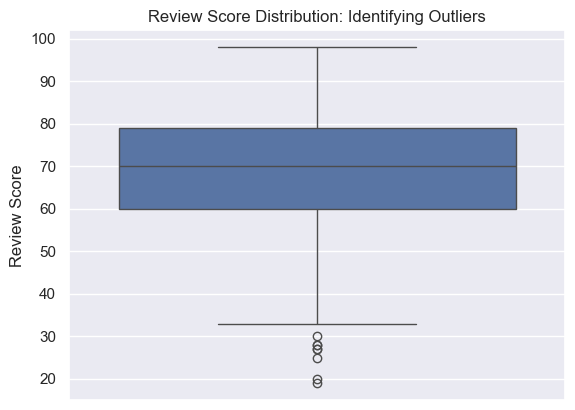

<Figure size 1500x1000 with 0 Axes>

In [10]:
sns.boxplot(data = df_clean["Metrics.Review Score"])
plt.ylabel('Review Score')
plt.title("Review Score Distribution: Identifying Outliers")
plt.figure(figsize=(15,10))
plt.show()

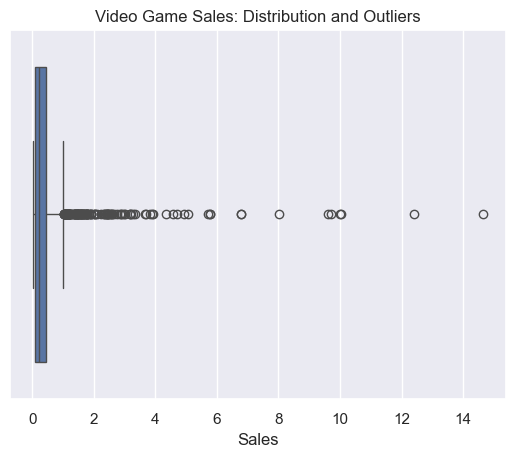

<Figure size 1500x1000 with 0 Axes>

In [11]:
sns.boxplot(x= df_clean["Metrics.Sales"])
plt.title("Video Game Sales: Distribution and Outliers")
plt.xlabel('Sales')
plt.figure(figsize=(15,10))
plt.show()

In [12]:
Q1 = df["Metrics.Sales"].quantile(0.25)
Q3 = df["Metrics.Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

new_df = df_clean[(df_clean["Metrics.Sales"] >= lower_bound) & (df_clean["Metrics.Sales"] <= upper_bound)]
new_df

,Metrics.Review Score,Metrics.Sales,Release.Console
1,89,0.56,Sony PSP
2,81,0.54,Nintendo DS
3,81,0.49,Sony PSP
4,61,0.45,Nintendo DS
5,67,0.41,Nintendo DS
...,...,...,...
1207,71,0.03,Nintendo DS
1208,62,0.03,Sony PSP
1209,51,0.03,PlayStation 3
1210,64,0.02,Nintendo Wii


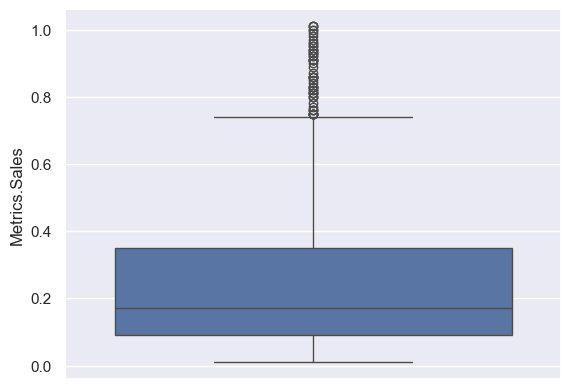

In [13]:
sns.boxplot(data = new_df["Metrics.Sales"])
plt.show()

In [14]:
new_rows_num = new_df.shape[0]
original_row_num - new_rows_num

134

### Conclusion:
Since `Metrics.Sales` exhibits a right-skewed distribution with extreme outliers, as shown in the boxplot above, I identified and removed 134 rows during the outlier cleaning process using the IQR method. The advantage of this approach is that it improving the accuracy of statistical analysis by reducing the influence of extreme values on calculations. However, the drawback is that the removed outliers may represent major blockbuster games that have had a significant impact on the gaming industry. Their exclusion could limit our ability to determine whether higher review scores are strongly correlated with exceptionally high sales.

### 3.3. Outlier Cleaning - Two Variable Outlier Inspection
1. Create a scatterplot of these two numerical variables.
2. Drop all significant outliers identified in the scatterplot.
3. Evaluate the pros and cons of dropping outliers.

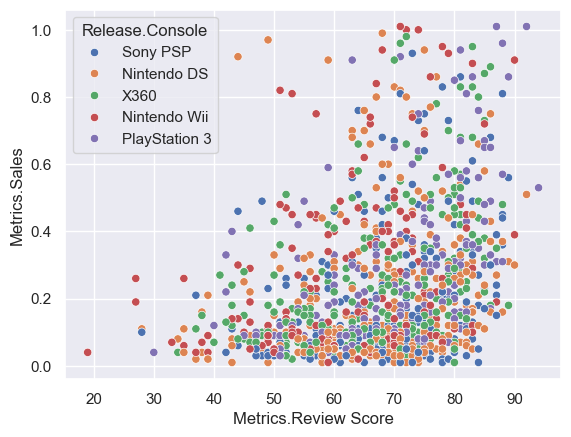

In [15]:
sns.scatterplot(x = "Metrics.Review Score", y = "Metrics.Sales", hue = "Release.Console", data = new_df)
plt.show()

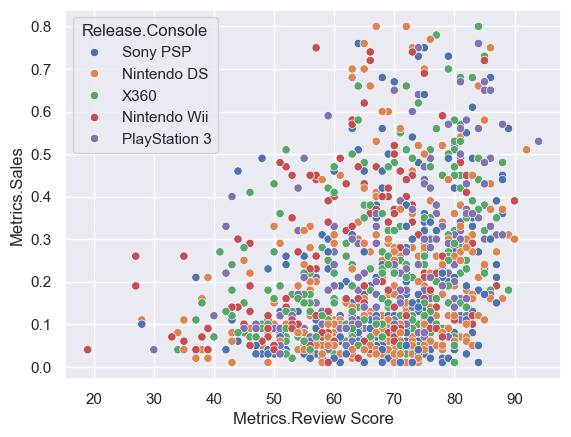

In [16]:
# check what happened if I drop the outliers.
new_df_2 = new_df[new_df["Metrics.Sales"] <= 0.8]
sns.scatterplot(x = "Metrics.Review Score", y = "Metrics.Sales", hue = "Release.Console", data = new_df_2)
plt.show()

### Conclusion:
Since I've already removed outliers for `Metrics.Sales` in the boxplot section, I decided not to remove the outliers again. 1. In the event that the outliers are far away from the best-fit line that exists for the non-outlier points, by deleting them this may improve performance for the non-outlier points. The linear regression model will thus be more effective at predicting the non-outlier points. However, if I delete these additional outliers, my model is technically not representative of the full original dataset. 

## 4. <u>Research Question</u>: How does the Relationship between `Metrics.Review Score` and `Metrics.Sales` Change base on Different Values `Release.Console` in the Dataset?


This question aims to explore whether review scores have a consistent impact on sales across different gaming consoles or if the relationship varies depending on the platform.

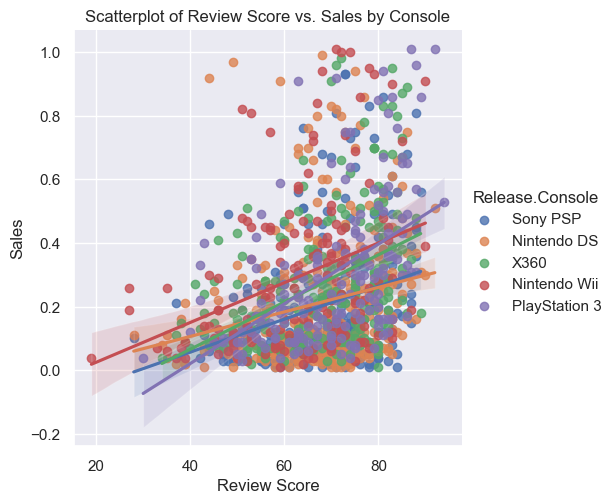

In [17]:
sns.lmplot(x="Metrics.Review Score", y="Metrics.Sales", hue="Release.Console",data=new_df)
plt.title("Scatterplot of Review Score vs. Sales by Console")
plt.xlabel("Review Score")
plt.ylabel("Sales")
plt.show()

### ***Sony PSP***, scatterplot and best fit line figure:

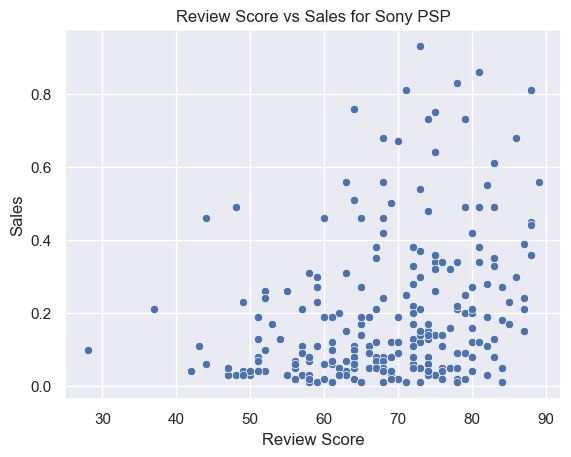

In [18]:
sony_psp = new_df[new_df['Release.Console'] == 'Sony PSP']
sns.scatterplot(x=sony_psp['Metrics.Review Score'], y=sony_psp['Metrics.Sales'],data = sony_psp)
plt.title('Review Score vs Sales for Sony PSP')
plt.xlabel('Review Score')
plt.ylabel('Sales')
plt.show()

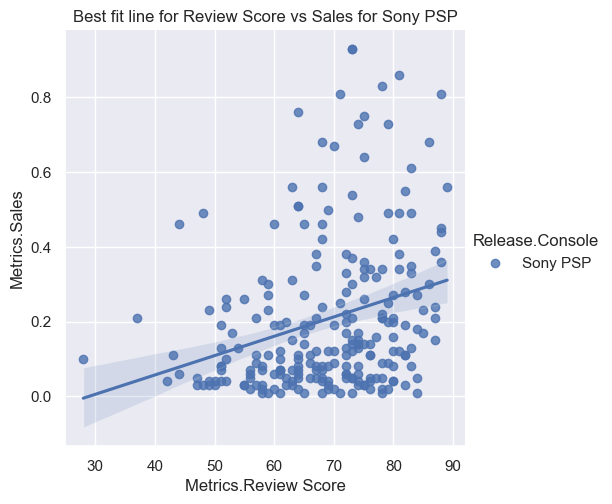

In [19]:
sns.lmplot(x='Metrics.Review Score',y= 'Metrics.Sales', hue = "Release.Console", data = sony_psp)
plt.title('Best fit line for Review Score vs Sales for Sony PSP')
plt.show()

### ***Nintendo DS***, scatterplot and best fit line figure:

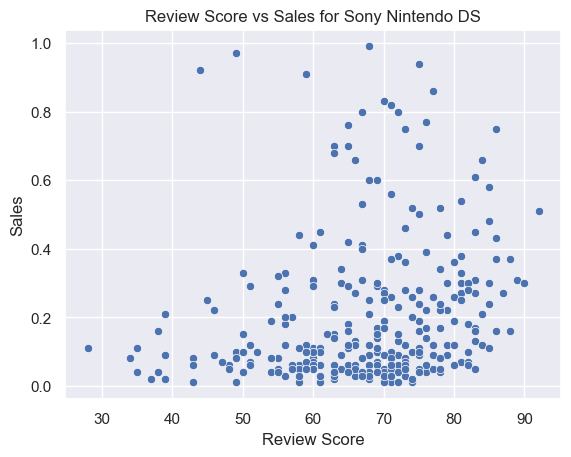

In [20]:
Nintendo_DS = new_df[new_df['Release.Console'] == 'Nintendo DS']
sns.scatterplot(x=Nintendo_DS['Metrics.Review Score'], y=Nintendo_DS['Metrics.Sales'],data = Nintendo_DS)
plt.title('Review Score vs Sales for Sony Nintendo DS')
plt.xlabel('Review Score')
plt.ylabel('Sales')
plt.show()

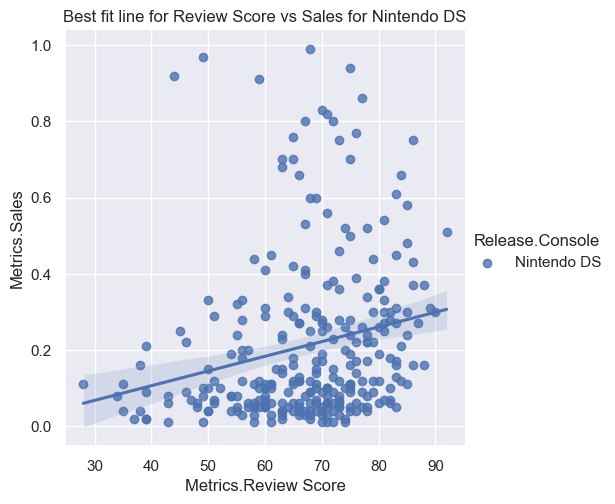

In [21]:
sns.lmplot(x='Metrics.Review Score',y= 'Metrics.Sales', hue = "Release.Console", data = Nintendo_DS)
plt.title('Best fit line for Review Score vs Sales for Nintendo DS')
plt.show()

### ***X360***, scatterplot and best fit line figure:

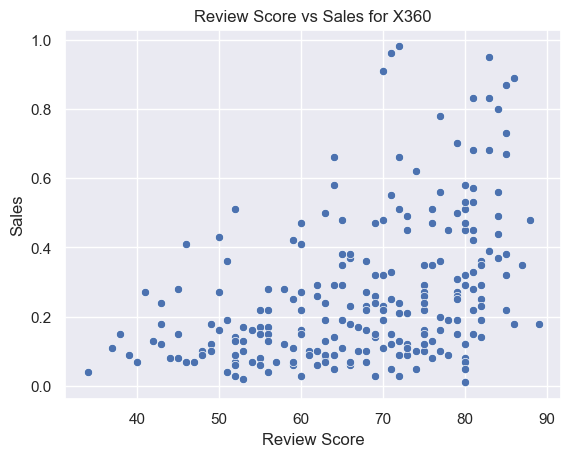

In [22]:
x360 = new_df[new_df['Release.Console'] == 'X360']
sns.scatterplot(x=x360['Metrics.Review Score'], y=x360['Metrics.Sales'],data = x360)
plt.title('Review Score vs Sales for X360')
plt.xlabel('Review Score')
plt.ylabel('Sales')
plt.show()

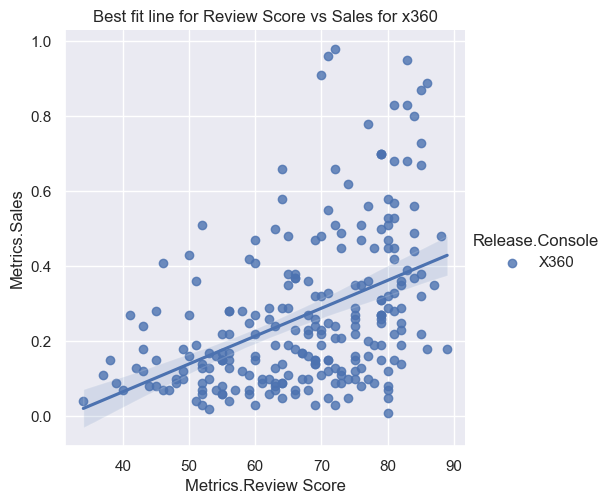

In [23]:
sns.lmplot(x='Metrics.Review Score',y= 'Metrics.Sales', hue = "Release.Console", data = x360)
plt.title('Best fit line for Review Score vs Sales for x360')
plt.show()

### ***Nintendo Wii***, scatterplot and best fit line:

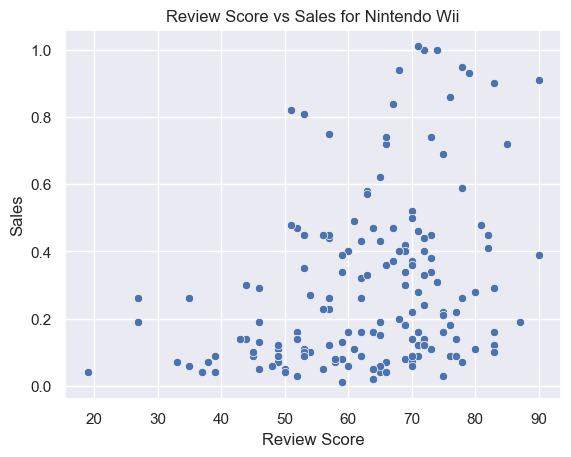

In [24]:
Nintendo_Wii = new_df[new_df['Release.Console'] == 'Nintendo Wii']
sns.scatterplot(x=Nintendo_Wii['Metrics.Review Score'], y=Nintendo_Wii['Metrics.Sales'],data = Nintendo_Wii)
plt.title('Review Score vs Sales for Nintendo Wii')
plt.xlabel('Review Score')
plt.ylabel('Sales')
plt.show()

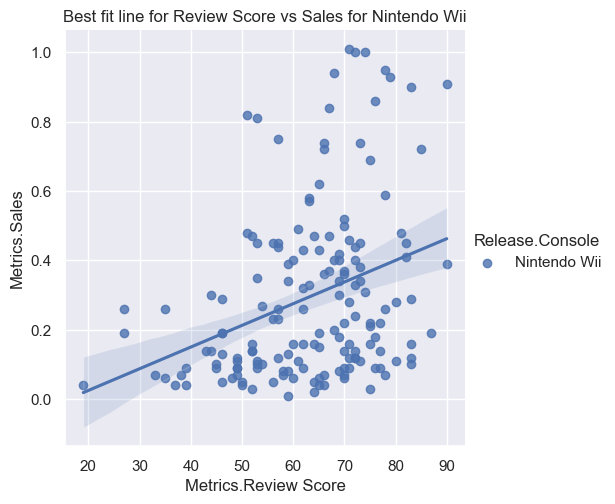

In [25]:
sns.lmplot(x='Metrics.Review Score',y= 'Metrics.Sales', hue = "Release.Console", data = Nintendo_Wii)
plt.title('Best fit line for Review Score vs Sales for Nintendo Wii')
plt.show()

### ***PlayStation 3***, scatterplot and best fit line:

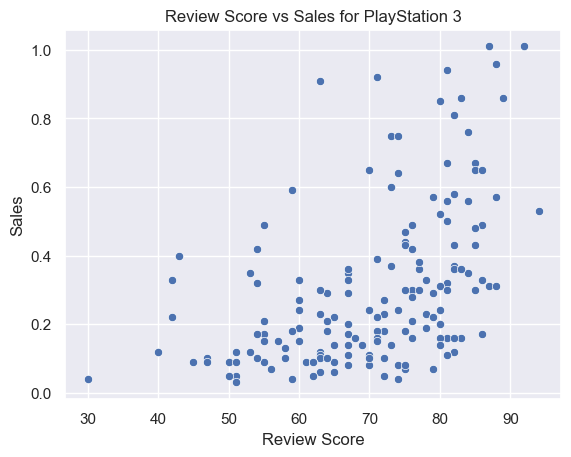

In [26]:
playStation_3 = new_df[new_df['Release.Console'] == 'PlayStation 3']
sns.scatterplot(x=playStation_3['Metrics.Review Score'], y=playStation_3['Metrics.Sales'],data = playStation_3)
plt.title('Review Score vs Sales for PlayStation 3')
plt.xlabel('Review Score')
plt.ylabel('Sales')
plt.show()

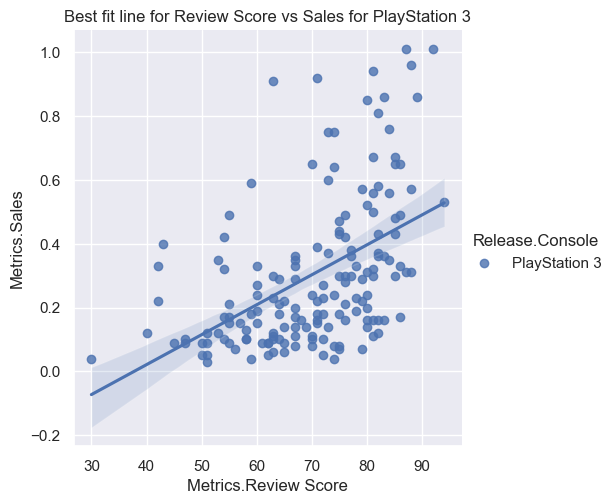

In [27]:
sns.lmplot(x='Metrics.Review Score',y= 'Metrics.Sales', hue = "Release.Console", data = playStation_3)
plt.title('Best fit line for Review Score vs Sales for PlayStation 3')
plt.show()

### Correlations for relationship across different platforms:

In [28]:
df[["Metrics.Review Score","Metrics.Sales","Release.Console"]].groupby(["Release.Console"]).corr()

Metrics.Review Score  Metrics.Sales
Release.Console                                                          
Nintendo DS     Metrics.Review Score              1.000000       0.260992
                Metrics.Sales                     0.260992       1.000000
Nintendo Wii    Metrics.Review Score              1.000000       0.241915
                Metrics.Sales                     0.241915       1.000000
PlayStation 3   Metrics.Review Score              1.000000       0.542888
                Metrics.Sales                     0.542888       1.000000
Sony PSP        Metrics.Review Score              1.000000       0.331150
                Metrics.Sales                     0.331150       1.000000
X360            Metrics.Review Score              1.000000       0.505820
                Metrics.Sales                     0.505820       1.000000

### Research Question Answer:

1. **Direction Changes:** The relationship between `Metrics.Review Score` and `Metrics.Sales` are positive across different `Release.Console`.
2. **Shape Changes:** The shape of relationship between `Metrics.Review Score` and `Metrics.Sales` are moderate linear for X360 and PlayStation 3, but for other three console platform are week linear.
3. **Strength Changes:** The strength of the relationship between `Metrics.Review Score` and `Metrics.Sales` is higher for the PlayStation 3 than other four consoles.
4. **Outlier Differences:** There are still have some outliers for all of the consoles.
5. **Slope Changes:** The slope of the relationship between `Metrics.Review Score` and `Metrics.Sales` is positive across consoles, but PlayStation 3 is steeper than other four consoles. 

## 5. Conclusion

### Summary:
By analyzing the correlation and scatter plots, we determined that only PlayStation 3 and X360 show a moderate linear relationship between `Metrics.Review Score` and `Metrics.Sales`, while Nintendo DS, Nintendo Wii, and Sony PSP exhibit a weak linear relationship. This suggests that correlation alone is not a reliable measure of the relationship strength across different console platforms, as it may lead to misleading interpretations.

Across all consoles, the direction of the relationship remains positive, meaning that higher review scores generally correspond to higher sales. However, the shape of the relationship varies, with X360 and PlayStation 3 displaying a more moderate linear trend, while the other three consoles exhibit weaker linearity. In terms of strength, PlayStation 3 shows the highest correlation between review scores and sales, followed by X360, while the other platforms display much weaker associations. Despite outlier removal using the IQR method, some extreme values still persist across all consoles, which may affect the observed trends. Finally, the slope of the relationship is positive across all consoles, but it is steepest for PlayStation 3, indicating that review scores have a greater impact on sales for this console compared to others.

### Shortcomings:
One of the key shortcomings of this analysis is that it relies heavily on linear correlation, which assumes a straight-line relationship between `Metrics.Review Score` and `Metrics.Sales`. However, the correlation suggest that the relationship is weakly linear for most consoles, meaning that other non-linear patterns may better explain the variation in sales. Additionally, while I removed outliers using the IQR method, some extreme values still persist, which could skew the correlation and regression results. These shortcomings impact how my research findings might be used in decision-making. If someone were to rely solely on my analysis to predict game sales based on review scores, they might overestimate the importance of reviews while overlooking other key business and consumer factors. 

### Future Work:
The idea for furture works, inculde try to use the  R-squared and residual scatterplot to evaluate the relationship between the two variables and exploring non-linear modeling or other machine learning approaches to better capture the relationship between `Metrics.Review Score` and `Metrics.Sales`. Moreover, I believe I need to learn new data analysis methods, analyze the data more deeply, and create more effective analysis reports.